Dataset Heart Disease DataSet sadrži medicinske podatke o pacijentima koji se koriste za analizu i proučavanje faktora povezanih sa srčanim oboljenjima. 
Podaci su prikupljeni na osnovu različitih medicinskih pregleda i testova, a često se koriste u istraživanjima iz oblasti mašinskog učenja i analize zdravstvenih podataka.

Skup podataka obuhvata informacije kao što su:

- demografske karakteristike pacijenata (starost, pol),

- simptomi koje pacijenti imaju (npr. tip bola u grudima),

- klinički parametri (krvni pritisak, nivo holesterola i šećera u krvi),

- rezultati medicinskih testova (EKG rezultati, maksimalni broj otkucaja srca i pojava angine tokom fizičke aktivnosti).

Ovaj dataset je pogodan za analizu zdravstvenih podataka i identifikovanje obrazaca koji mogu ukazivati na povećan rizik od srčanih oboljenja.

Cilj klasterizacije je da:

- grupiše pacijente sa sličnim medicinskim karakteristikama,

- identifikuje potencijalne rizične grupe,

- otkrije skrivene obrasce u podacima koji mogu pomoći u boljem razumevanju faktora rizika za srčane bolesti.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


df = pd.read_csv("heart_disease.csv")
df.head()

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df = df.drop(columns=['id'])

Izbaciti kolone sa previše missing vrednosti

In [ ]:
df = df.drop(columns=['ca','thal','slope'])

Popuniti numeričke kolone medianom

In [ ]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

Kategorijske kolone popuniti najčešćom vrednošću

In [ ]:
df['fbs'] = df['fbs'].astype(str).fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].astype(str).fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].astype(str).fillna(df['exang'].mode()[0]) 

Trazimo numericke kolone za kategorisanje

In [ ]:
# Prikaz numeričkih kolona
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeričke kolone:", numerical_cols)

# Prikaz kategorijskih kolona
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kategorijske kolone:", categorical_cols)

df_copy = df.copy()

df_copy.describe()

Numeričke kolone: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
Kategorijske kolone: Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang'], dtype='object')


,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


# Outlieri

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_copy.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df_copy.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


In [ ]:
Q1 = df_copy['chol'].quantile(0.25)
Q3 = df_copy['chol'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['chol'] < lower_bound) | (df_copy['chol'] > upper_bound)]

print("Outlieri:")
print(outliers)

In [ ]:
import numpy as np

df_copy['chol'] = df_copy['chol'].replace(0, np.nan)
df_copy['trestbps'] = df_copy['trestbps'].replace(0, np.nan)
df_copy['thalch'] = df_copy['thalch'].replace(0, np.nan)

df_copy['chol'] = df_copy['chol'].fillna(df_copy['chol'].median())
df_copy['trestbps'] = df_copy['trestbps'].fillna(df_copy['trestbps'].median())
df_copy['thalch'] = df_copy['thalch'].fillna(df_copy['thalch'].median())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_copy.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
print((df_copy[['chol','trestbps','thalch']] == 0).sum())

# Analiza outliera

### Napraviti kopiju data seta

In [ ]:
df_no_outliers = df_copy.copy()

### Ciscenje outliera

In [ ]:
numerical_cols_to_clip = ['age','trestbps','chol','thalch','oldpeak']

for col in numerical_cols_to_clip:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)

### Vizualizacija ROC krive

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_with, tpr_with, _ = roc_curve(y_test_with, y_pred_with)
fpr_no, tpr_no, _ = roc_curve(y_test_no, y_pred_no)

plt.figure(figsize=(6,5))
plt.plot(fpr_with, tpr_with, label=f"Sa outlierima (AUC={auc_with:.2f})")
plt.plot(fpr_no, tpr_no, label=f"Bez outliera (AUC={auc_no:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krive: Sa i bez outliera")
plt.legend()
plt.show()

In [ ]:
# Ciljna kolona i ulazne kolone
y = df['num'].apply(lambda x: 1 if x > 0 else 0)
X = df.drop(columns=['num'], errors='ignore') 

# Numeričke i kategorijske kolone
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Skaliranje numeričkih i enkodiranje kategorijskih kolona
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])
X_processed = preprocessor.fit_transform(X)
X_processed = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Konvertovanje y u 1D nizove
y_train = y_train.to_numpy().astype('int32')
y_val = y_val.to_numpy().astype('int32')
y_test = y_test.to_numpy().astype('int32')

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
# Kreiranje modela
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    Dense(32, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    Dense(16, kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,   # smanji sa 5
    restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-4,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)

# Evaluacija na test skupu
loss, accuracy, auc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - AUC: 0.4841 - accuracy: 0.4847 - loss: 0.8241 - val_AUC: 0.5058 - val_accuracy: 0.4595 - val_loss: 0.7169 - learning_rate: 5.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.5863 - accuracy: 0.5459 - loss: 0.7289 - val_AUC: 0.6419 - val_accuracy: 0.5946 - val_loss: 0.6837 - learning_rate: 5.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.6980 - accuracy: 0.6395 - loss: 0.6460 - val_AUC: 0.7249 - val_accuracy: 0.6622 - val_loss: 0.6575 - learning_rate: 5.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7468 - accuracy: 0.6922 - loss: 0.6172 - val_AUC: 0.7715 - val_accuracy: 0.7162 - val_loss: 0.6338 - learning_rate: 5.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7945 - accuracy: 0.7381 - loss: 0.5671 - val_AUC: 0.8006 - val_accuracy: 0.7297 - val_loss: 0.6105 - learning_rate: 5.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.8149 - acc

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.8756 - accuracy: 0.7942 - loss: 0.4501 - val_AUC: 0.8571 - val_accuracy: 0.7770 - val_loss: 0.4852 - learning_rate: 5.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8746 - accuracy: 0.7874 - loss: 0.4530 - val_AUC: 0.8577 - val_accuracy: 0.7770 - val_loss: 0.4827 - learning_rate: 5.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8772 - accuracy: 0.8231 - loss: 0.4492 - val_AUC: 0.8583 - val_accuracy: 0.7703 - val_loss: 0.4792 - learning_rate: 5.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8764 - accuracy: 0.8112 - loss: 0.4485 - val_AUC: 0.8609 - val_accuracy: 0.7703 - val_loss: 0.4781 - learning_rate: 5.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8792 - accuracy: 0.8010 - loss: 0.4429 - val_AUC: 0.8642 - val_accuracy: 0.7703 - val_loss: 0.4750 - learning_rate: 5.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8845 - accu

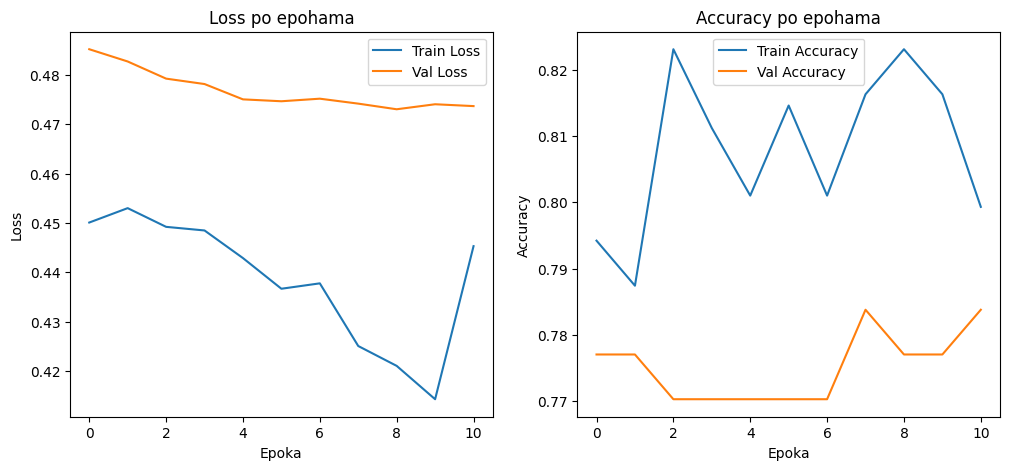

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss po epohama')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy po epohama')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)